# Modelo sin embeddings

In [1]:
import pickle
import pandas as pd
import numpy as np

pd.set_option("display.max_rows", None)   # Muestra todas las filas
pd.set_option("display.max_columns", None)  # Muestra todas las columnas
pd.set_option("display.width", None)     # No corta la tabla en varias líneas
pd.set_option("display.max_colwidth", None)  # Muestra el contenido de celdas completo

In [2]:
with open("../data/normalized/df_normalized.pk1", "rb") as f:
    df_data = pickle.load(f)

In [3]:
# Se copian los datos
df_model = df_data.copy()

In [4]:
df_model.dtypes

ride_id                                 object
started_at                      datetime64[ns]
ended_at                        datetime64[ns]
start_station_id                        object
end_station_id                          object
member_casual                           object
year                                     int64
month                                    int64
day                                      int64
time_hms_ms                    timedelta64[ns]
event                                     bool
temperature                            float64
wind_speed                             float64
relative_humidity                      float64
rideable_type_classic_bike                bool
rideable_type_docked_bike                 bool
rideable_type_electric_bike               bool
member_casual_bool                        bool
day_type_Holiday                          bool
day_type_Normal                           bool
day_type_Weekend                          bool
temp_std     

In [5]:
df_model.head(5)

,ride_id,started_at,ended_at,start_station_id,end_station_id,member_casual,year,month,day,time_hms_ms,event,temperature,wind_speed,relative_humidity,rideable_type_classic_bike,rideable_type_docked_bike,rideable_type_electric_bike,member_casual_bool,day_type_Holiday,day_type_Normal,day_type_Weekend,temp_std,wind_std,rel_humidity_std,start_station_idx,end_station_idx,hour_float,hour_sin,hour_cos,month_sin,month_cos,duration_min
0,98D355D9A9852BE9,2022-01-01 00:00:05,2022-01-01 00:01:48,623,623,casual,2022,1,1,0 days 00:00:05,False,7.8,2.1,83.0,True,False,False,True,True,False,False,-0.996614,-1.035159,1.399734,1013,1013,0.001389,0.000364,1.000000,0.5,0.866025,1.716667
1,04706CA7F5BD25EE,2022-01-01 00:01:00,2022-01-01 00:04:39,13325,13137,casual,2022,1,1,0 days 00:01:00,False,7.8,2.1,83.0,False,False,True,True,True,False,False,-0.996614,-1.035159,1.399734,367,300,0.016667,0.004363,0.999990,0.5,0.866025,3.650000
2,42178E850B92597A,2022-01-01 00:01:16,2022-01-01 00:32:14,TA1305000009,TA1305000009,casual,2022,1,1,0 days 00:01:16,False,7.8,2.1,83.0,False,False,True,True,True,False,False,-0.996614,-1.035159,1.399734,1533,1533,0.021111,0.005527,0.999985,0.5,0.866025,30.966667
3,6B93C46E8F5B114C,2022-01-01 00:02:14,2022-01-01 00:31:07,623,623,casual,2022,1,1,0 days 00:02:14,False,7.8,2.1,83.0,True,False,False,True,True,False,False,-0.996614,-1.035159,1.399734,1013,1013,0.037222,0.009745,0.999953,0.5,0.866025,28.883333
4,466943353EAC8022,2022-01-01 00:02:35,2022-01-01 00:31:04,623,623,casual,2022,1,1,0 days 00:02:35,False,7.8,2.1,83.0,True,False,False,True,True,False,False,-0.996614,-1.035159,1.399734,1013,1013,0.043056,0.011272,0.999936,0.5,0.866025,28.483333


In [6]:
len(df_model)

9969971

# Se agrupan los datos por estaciones y por intervalo de tiempo

In [7]:
df_model['datetime_hour'] = df_model['started_at'].dt.floor('H')

df_model['datetime_hour'].head(10)

C:\Users\burvu\AppData\Local\Temp\ipykernel_29184\1090642612.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_model['datetime_hour'] = df_model['started_at'].dt.floor('H')


0   2022-01-01
1   2022-01-01
2   2022-01-01
3   2022-01-01
4   2022-01-01
5   2022-01-01
6   2022-01-01
7   2022-01-01
8   2022-01-01
9   2022-01-01
Name: datetime_hour, dtype: datetime64[ns]

In [8]:
len(df_model)

9969971

In [9]:
df_model[['start_station_idx', 'end_station_idx']].nunique()

start_station_idx    1669
end_station_idx      1679
dtype: int64

In [10]:
# Agregar los viajes
df_counts = df_model.groupby(
    ['start_station_idx', 'end_station_idx', 'datetime_hour']
).agg({
    'temp_std': 'mean',
    'wind_std': 'mean',
    'rel_humidity_std': 'mean',
    'event': 'first',
    'day_type_Holiday': 'first',
    'day_type_Normal': 'first',
    'day_type_Weekend': 'first',
    'hour_float': 'first',
    'hour_sin': 'first',
    'hour_cos': 'first',
    'month_sin': 'first',
    'month_cos': 'first',
    'year': 'first',
    # cuenta de viajes
    'start_station_idx': 'count'
}).rename(columns={'start_station_idx': 'trip_count'}).reset_index()

In [11]:
df_counts.iloc[10000:10010]

,start_station_idx,end_station_idx,datetime_hour,temp_std,wind_std,rel_humidity_std,event,day_type_Holiday,day_type_Normal,day_type_Weekend,hour_float,hour_sin,hour_cos,month_sin,month_cos,year,trip_count
10000,253,256,2022-09-01 16:00:00,1.385319,-0.884344,-1.143772,True,False,True,False,16.665000,-0.939543,-0.342430,-1.0,-1.836970e-16,2022,1
10001,253,256,2022-09-01 17:00:00,1.423578,-0.177734,-1.193720,True,False,True,False,17.310556,-0.983755,-0.179518,-1.0,-1.836970e-16,2022,1
10002,253,256,2022-09-02 12:00:00,0.614770,-0.790180,0.654356,True,False,True,False,12.356389,-0.093167,-0.995650,-1.0,-1.836970e-16,2022,1
10003,253,256,2022-09-06 11:00:00,0.447192,-1.310759,1.169205,False,False,True,False,11.673611,0.085344,-0.996352,-1.0,-1.836970e-16,2022,1
10004,253,256,2022-09-06 17:00:00,0.900761,-0.545201,-0.025705,False,False,True,False,17.822778,-0.998924,-0.046380,-1.0,-1.836970e-16,2022,1
10005,253,256,2022-09-07 17:00:00,0.943579,0.192286,-0.810145,False,False,True,False,17.192222,-0.977722,-0.209903,-1.0,-1.836970e-16,2022,3
10006,253,256,2022-09-08 11:00:00,0.094030,-1.999762,0.996308,False,False,True,False,11.891667,0.028358,-0.999598,-1.0,-1.836970e-16,2022,1
10007,253,256,2022-09-08 17:00:00,1.073533,-0.602618,-1.085179,False,False,True,False,17.772500,-0.998227,-0.059524,-1.0,-1.836970e-16,2022,1
10008,253,256,2022-09-09 12:00:00,0.230621,-1.074202,0.287431,False,False,True,False,12.540278,-0.140973,-0.990013,-1.0,-1.836970e-16,2022,1
10009,253,256,2022-09-09 15:00:00,0.784282,-0.192756,-0.437976,False,False,True,False,15.288056,-0.758371,-0.651823,-1.0,-1.836970e-16,2022,1


In [12]:
X_context = df_counts[['temp_std', 'wind_std', 'rel_humidity_std', 'event', 'day_type_Holiday', 'day_type_Normal', 'day_type_Weekend', 'hour_float', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'year']]
X_start = df_counts['start_station_idx']
X_end = df_counts['end_station_idx']
y = df_counts['trip_count']

In [13]:
with open("../data/normalized/le_station_encoder.pkl", "rb") as f:
    le_station = pickle.load(f)
    
len(le_station.classes_)

1695

# Se contrstruye el modelo

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam
import numpy as np
from tensorflow.keras.losses import Huber

num_stations = len(le_station.classes_)
num_features = X_context.shape[1]

print(f"Number of stations: {num_stations}")
print(f"Number of features: {num_features}")

# ============================================================
# 4️⃣ Dividir datos en train/test
# ============================================================
(
    X_train, X_test,
    start_train, start_test,
    end_train, end_test,
    y_train, y_test
) = train_test_split(
    X_context, X_start, X_end, y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# 5️⃣ Preparar los tensores de entrada
# ============================================================
X_train_context = X_train.values.astype(np.float32)
X_test_context  = X_test.values.astype(np.float32)

start_train_input = start_train.values.reshape(-1, 1).astype(np.float32)
start_test_input  = start_test.values.reshape(-1, 1).astype(np.float32)

end_train_input = end_train.values.reshape(-1, 1).astype(np.float32)
end_test_input  = end_test.values.reshape(-1, 1).astype(np.float32)

y_train = y_train.values.astype(np.float32)
y_test  = y_test.values.astype(np.float32)

# ============================================================
# 6️⃣ Modelo SIN embeddings
# ============================================================
context_input = Input(shape=(num_features,), name="context")
start_input   = Input(shape=(1,), name="start_station_input")
end_input     = Input(shape=(1,), name="end_station_input")

# Concatenamos las entradas directamente
x = layers.Concatenate()([start_input, end_input, context_input])

# Capas densas
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(1, activation='linear')(x)

# Construcción y compilación
model = Model(inputs=[start_input, end_input, context_input], outputs=output)
model.compile(optimizer=Adam(1e-3), loss='mae', metrics=['mae'])
model.summary()


Number of stations: 1695
Number of features: 13


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ start_station_input │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ end_station_input   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context             │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 15)        │          0 │ start_station_in… │
│ (Concatenate)       │                   │            │ end_station_inpu… │
│                     │                   │            │ context[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │      4,096 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     32,896 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 45,313 (177.00 KB)

 Trainable params: 45,313 (177.00 KB)

 Non-trainable params: 0 (0.00 B)

🔹 2️⃣ Por qué se usa en problemas de regresión como el tuyo

Tu variable objetivo (y) —probablemente número de viajes entre estaciones o similar—
tiene una distribución muy asimétrica (sesgada a la derecha):

muchos valores pequeños (pocos viajes),

unos pocos valores muy grandes (rutas muy transitadas).

Eso provoca que:

el modelo aprenda peor los valores pequeños,

y se concentre en minimizar los grandes errores de los valores enormes.

El logaritmo soluciona eso porque comprime los valores grandes y expande los pequeños,
haciendo la distribución más simétrica y estable numéricamente.

🔹 3️⃣ Ventajas directas
Problema sin log	Efecto del log1p
Distribución muy sesgada	La hace más normal (gaussiana)
Grandes diferencias entre valores	Reduce la escala y estabiliza
Gradientes inestables (explosivos)	Suaviza y acelera el entrenamiento
Pérdida dominada por valores grandes	Equilibra el error entre pequeños y grandes

In [ ]:
y_train_scaled = np.log1p(y_train)
y_test_scaled = np.log1p(y_test)

# y_train_scaled = y_train
# y_test_scaled = y_test

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

# ---------- Callbacks
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ---------- Entrenamiento
history = model.fit(
    [start_train_input, end_train_input, X_train_context],
    y_train_scaled,
    validation_data=([start_test_input, end_test_input, X_test_context], y_test_scaled),
    epochs=5,
    batch_size=128,
    callbacks=[callback],
    verbose=1
)

Epoch 1/5
53772/53772 ━━━━━━━━━━━━━━━━━━━━ 76s 1ms/step - loss: 0.0918 - mae: 0.2520 - val_loss: 0.0916 - val_mae: 0.2484
Epoch 2/5
53772/53772 ━━━━━━━━━━━━━━━━━━━━ 75s 1ms/step - loss: 0.0918 - mae: 0.2520 - val_loss: 0.0916 - val_mae: 0.2485
Epoch 3/5
53772/53772 ━━━━━━━━━━━━━━━━━━━━ 81s 1ms/step - loss: 0.0918 - mae: 0.2520 - val_loss: 0.0916 - val_mae: 0.2514
Epoch 4/5
53772/53772 ━━━━━━━━━━━━━━━━━━━━ 75s 1ms/step - loss: 0.0918 - mae: 0.2520 - val_loss: 0.0916 - val_mae: 0.2496
Epoch 5/5
53772/53772 ━━━━━━━━━━━━━━━━━━━━ 75s 1ms/step - loss: 0.0918 - mae: 0.2520 - val_loss: 0.0916 - val_mae: 0.2487


In [34]:
test_loss, test_mae = model.evaluate(
    [start_test_input, end_test_input, X_test_context],
    y_test_scaled,
    verbose=0
)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test Loss (MSE): 0.0916
Test MAE: 0.2514


In [ ]:
y_pred_scaled = model.predict([start_test_input, end_test_input, X_test_context])

y_pred_real = np.square(y_pred_scaled)
y_test_real = np.square(y_test_scaled)

# y_pred_real = y_pred_scaled
# y_test_real = y_test_scaled

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2 = r2_score(y_test_real, y_pred_real)
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")


53772/53772 ━━━━━━━━━━━━━━━━━━━━ 37s 696us/step
MAE: 0.251, RMSE: 0.527, R²: -0.005


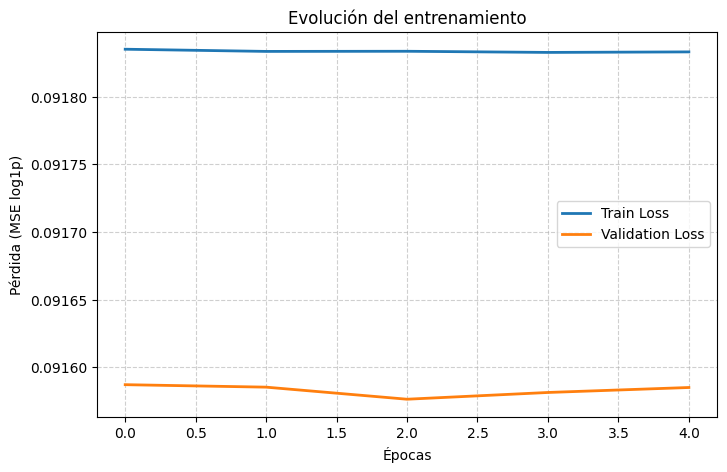

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE log1p)')
plt.title('Evolución del entrenamiento')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

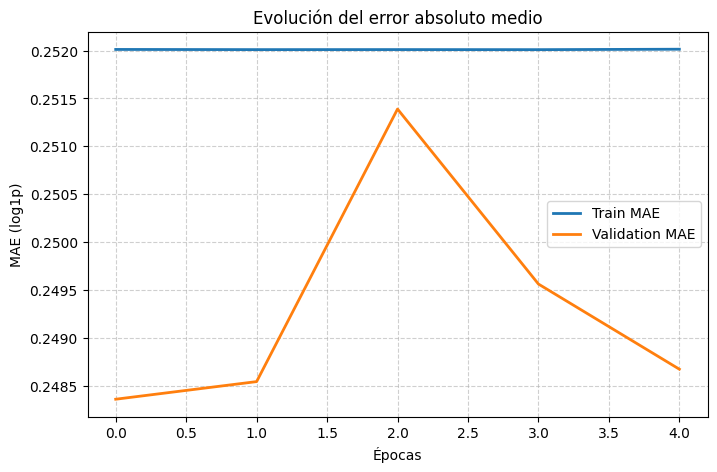

In [37]:
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
plt.xlabel('Épocas')
plt.ylabel('MAE (log1p)')
plt.title('Evolución del error absoluto medio')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [38]:
import json

model.save("modelSave/model_9_12.keras")

with open('modelSave/history_9_12.json', 'w') as f:
    json.dump(history.history, f)